<a href="https://colab.research.google.com/github/Bungaindah186/Klasifikasi-Citra-dengan-CNN-Dari-Awal-hingga-Transfer-Learning/blob/main/Tugas14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step

Training CNN From Scratch...
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 44ms/step - accuracy: 0.3546 - loss: 1.7517 - val_accuracy: 0.4393 - val_loss: 1.5444
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.4708 - loss: 1.4613 - val_accuracy: 0.5742 - val_loss: 1.1893
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.5282 - loss: 1.3162 - val_accuracy: 0.6044 - val_loss: 1.1160
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.5638 - loss: 1.2269 - val_accuracy: 0.6027 - val_loss: 1.1497
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 36ms/step - accuracy: 0.5901 - loss: 1.1601 - val_accuracy: 0.6324 - val_loss: 1.0275
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.6058 - loss: 1.1167 - val_accuracy: 0.6414 - val_loss: 1.0324
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.6254 - loss: 1.0649 - val_accuracy: 0.6506 - val_loss: 1.0327
Epoch 

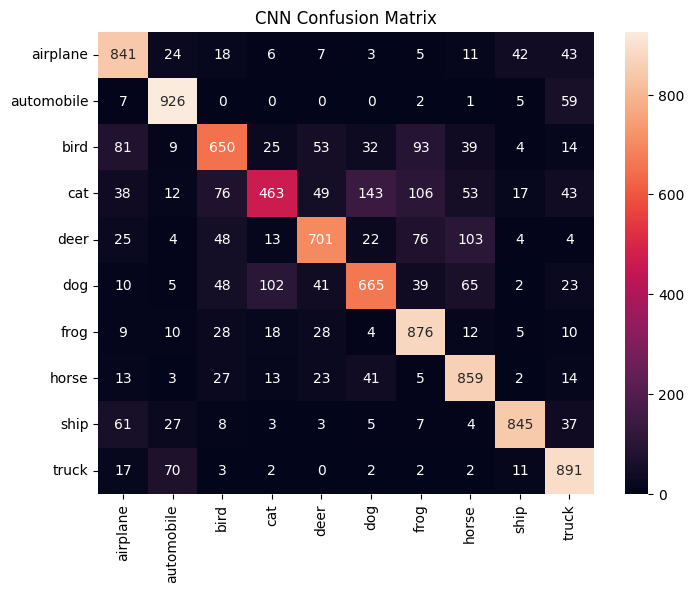

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


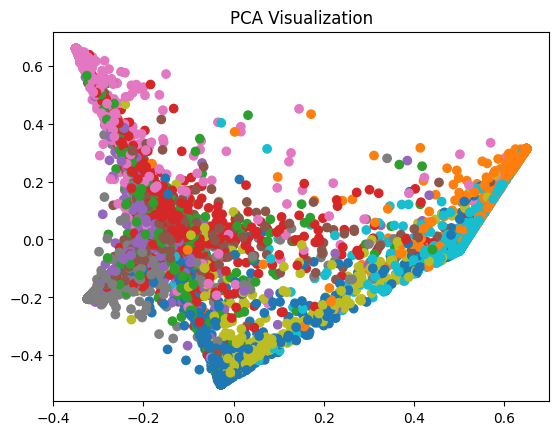

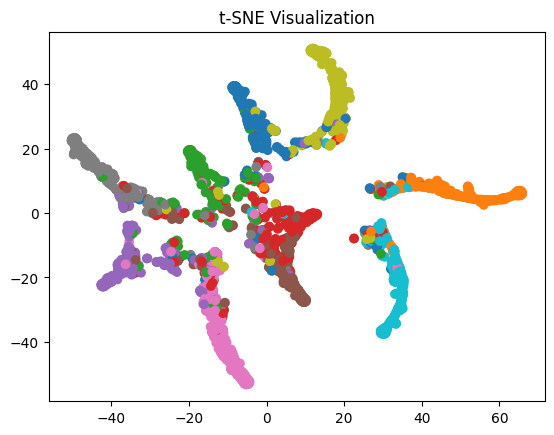

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


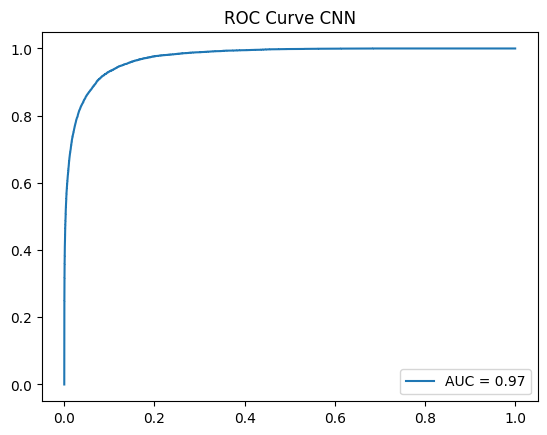


================ FINAL RESULT ================
CNN Accuracy: 0.7717000246047974
MobileNetV2 Accuracy: 0.1000
VGG16 Accuracy: 0.1000
ResNet50 Accuracy: 0.2425


In [ ]:
"""
=================================================================================
FINAL PROJECT: KLASIFIKASI CITRA CNN + TRANSFER LEARNING
Dataset: CIFAR-10
Model: CNN From Scratch + MobileNetV2 + VGG16 + ResNet50
=================================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import time
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# =========================
# SETUP
# =========================
np.random.seed(42)
tf.random.set_seed(42)

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']
num_classes = 10

# =========================
# LOAD DATA
# =========================
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Resize untuk transfer learning
X_train_tl = tf.image.resize(X_train, (96, 96))
X_test_tl = tf.image.resize(X_test, (96, 96))

# =========================
# AUGMENTATION
# =========================
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

# =========================
# CALLBACKS
# =========================
early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

checkpoint = callbacks.ModelCheckpoint(
    "best_model.keras",
    save_best_only=True,
    monitor="val_accuracy"
)

# =========================
# CNN FROM SCRATCH
# =========================
def build_cnn():
    model = models.Sequential([
        layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(32,32,3)),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# =========================
# TRANSFER LEARNING BUILDER
# =========================
def build_tl(model_name):

    if model_name == "MobileNetV2":
        base = keras.applications.MobileNetV2(
            include_top=False,
            weights="imagenet",
            input_shape=(96,96,3)
        )
        preprocess = keras.applications.mobilenet_v2.preprocess_input

    elif model_name == "VGG16":
        base = keras.applications.VGG16(
            include_top=False,
            weights="imagenet",
            input_shape=(96,96,3)
        )
        preprocess = keras.applications.vgg16.preprocess_input

    else:
        base = keras.applications.ResNet50(
            include_top=False,
            weights="imagenet",
            input_shape=(96,96,3)
        )
        preprocess = keras.applications.resnet50.preprocess_input

    base.trainable = False

    inputs = keras.Input(shape=(96,96,3))
    x = preprocess(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs)

# =========================
# TRAIN CNN
# =========================
cnn = build_cnn()
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

print("\nTraining CNN From Scratch...")
history_cnn = cnn.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint]
)

# =========================
# TRAIN TRANSFER LEARNING
# =========================
tl_models = {}
results = {}

for name in ["MobileNetV2", "VGG16", "ResNet50"]:

    print(f"\nTraining {name}...")

    model = build_tl(name)
    model.compile(
        optimizer=optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    start = time.time()

    history = model.fit(
        datagen.flow(X_train_tl, y_train, batch_size=64),
        epochs=10,
        validation_data=(X_test_tl, y_test),
        callbacks=[early_stop],
        verbose=1
    )

    time_taken = time.time() - start

    acc = model.evaluate(X_test_tl, y_test, verbose=0)[1]

    tl_models[name] = model
    results[name] = acc

    print(f"{name} Accuracy: {acc:.4f} | Time: {time_taken:.2f}s")

# =========================
# CONFUSION MATRIX CNN
# =========================
y_pred = np.argmax(cnn.predict(X_test), axis=1)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("CNN Confusion Matrix")
plt.show()

# =========================
# PCA + TSNE VISUALIZATION
# =========================
features = cnn.predict(X_test)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

plt.figure()
plt.scatter(pca_result[:,0], pca_result[:,1], c=y_test.squeeze(), cmap='tab10')
plt.title("PCA Visualization")
plt.show()

tsne = TSNE(n_components=2, perplexity=30)
tsne_result = tsne.fit_transform(features[:2000])

plt.figure()
plt.scatter(tsne_result[:,0], tsne_result[:,1],
            c=y_test[:2000].squeeze(), cmap='tab10')
plt.title("t-SNE Visualization")
plt.show()

# =========================
# ROC-AUC MULTI CLASS
# =========================
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

cnn_prob = cnn.predict(X_test)

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), cnn_prob.ravel())
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.title("ROC Curve CNN")
plt.legend()
plt.show()

# =========================
# FINAL SUMMARY
# =========================
print("\n================ FINAL RESULT ================")
print("CNN Accuracy:", cnn.evaluate(X_test, y_test, verbose=0)[1])

for k,v in results.items():
    print(f"{k} Accuracy: {v:.4f}")